# Quantum-Boosted Spectrum Allocation — Demo

End-to-end demo for the ISIT 2026 QHack Napkin Pitch / final.

**Pipeline:** interference graph → coloring QUBO → cold QAOA baseline → warm-start QAOA under mobility dynamics → fixed-budget comparison as the headline result → encoding note as an appendix.

Run from the project root with the project venv active.


In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from src.graphs import small_graph, midsize_graph, generate_interference_graph, mobility_sequence
from src.qubo import build_encoding, interference_objective, _keff
from src.baselines import brute_force, greedy_dfs
from src.solve_qaoa import solve_cold, solve_warm
from src.dynamics import run_dynamics
from src.encoding_study import study as encoding_study, print_table

np.random.seed(42)
print('imports OK')

imports OK


## 1. Interference graph

Small-cell network as a weighted graph: nodes = cells, edges = interfering pairs, edge weight = interference coupling (decreasing in distance).

8 cells, 26 interfering edges, K=3 channels
edge weight range: 0.119 .. 1.000


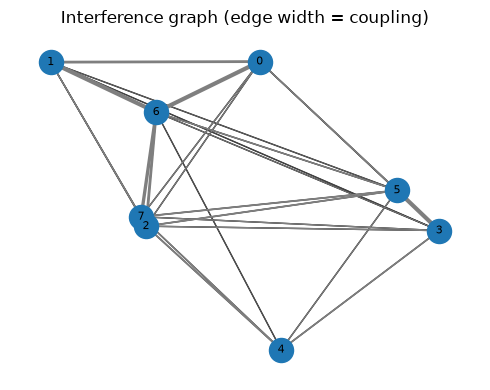

In [2]:
ig = small_graph(seed=1)
print(f'{ig.n_cells} cells, {ig.graph.number_of_edges()} interfering edges, K={ig.n_channels} channels')
print(f'edge weight range: {min(ig.weights.values()):.3f} .. {max(ig.weights.values()):.3f}')

fig, ax = plt.subplots(figsize=(5,4))
pos = ig.positions
nx.draw(ig.graph, pos, ax=ax, node_color='tab:blue', with_labels=True, node_size=300, font_size=8)
weights = [3*ig.graph[u][v]['weight'] for u,v in ig.graph.edges()]
nx.draw_networkx_edges(ig.graph, pos, ax=ax, width=weights, edge_color='tab:gray')
ax.set_title('Interference graph (edge width = coupling)')
plt.tight_layout(); plt.show()

## 2. QUBO correctness vs brute force (verification check #1)

The coloring QUBO's argmin must match the brute-force minimum interference, in both encodings.

In [3]:
import itertools
bf_assign, bf_obj = brute_force(ig)
gd_assign, gd_obj = greedy_dfs(ig)
print(f'brute-force optimum interference = {bf_obj:.4f}')
print(f'greedy            interference = {gd_obj:.4f}  (gap {gd_obj-bf_obj:.4f})')

# Evaluate the QUBO over all feasible one-hot bitstrings; its argmin must equal brute force.
def onehot_argmin_interference(ig, penalty):
    N, K = ig.n_cells, ig.n_channels
    best = (None, 1e18)
    for combo in itertools.product(range(K), repeat=N):
        x = np.zeros(N*K)
        for v,c in enumerate(combo): x[v*K+c] = 1
        enc = build_encoding(ig, encoding='onehot', penalty=penalty)
        if enc.qp.objective.evaluate(x) < best[1]:
            best = (combo, enc.qp.objective.evaluate(x))
    return interference_objective(ig, dict(enumerate(best[0])))

def binary_argmin_interference(ig, penalty):
    N, K = ig.n_cells, ig.n_channels
    Ke = _keff(K)
    best = (None, 1e18)
    for bits in itertools.product(range(2), repeat=N*Ke):
        x = np.array(bits, dtype=float)
        enc = build_encoding(ig, encoding='binary', penalty=penalty)
        if enc.qp.objective.evaluate(x) < best[1]:
            best = (bits, enc.qp.objective.evaluate(x))
    enc = build_encoding(ig, encoding='binary', penalty=penalty)
    return interference_objective(ig, enc.decode(np.array(best[0], dtype=float)))

oh = onehot_argmin_interference(ig, penalty=6.0)
bn = binary_argmin_interference(ig, penalty=6.0)
print(f'one-hot QUBO argmin decoded interference = {oh:.4f}  | matches brute: {abs(oh-bf_obj)<1e-9}')
print(f'binary  QUBO argmin decoded interference = {bn:.4f}  | matches brute: {abs(bn-bf_obj)<1e-9}')
print(f'qubits: one-hot={ig.n_cells*ig.n_channels}  binary={ig.n_cells*_keff(ig.n_channels)}')

brute-force optimum interference = 1.8057
greedy            interference = 1.8532  (gap 0.0475)
one-hot QUBO argmin decoded interference = 1.8057  | matches brute: True
binary  QUBO argmin decoded interference = 1.8057  | matches brute: True
qubits: one-hot=24  binary=16


## 3. Cold QAOA vs brute force (verification check #4)

Cold-start QAOA on the one-hot QUBO, on Aer statevector. Should match or beat greedy and approach the brute-force optimum.

cold QAOA:   interference=2.3255  feasible=True  iters=25  gap=0.5198
brute force: 1.8057   greedy: 1.8532
assignment: {0: 2, 1: 2, 2: 2, 3: 1, 4: 2, 5: 0, 6: 1, 7: 0}


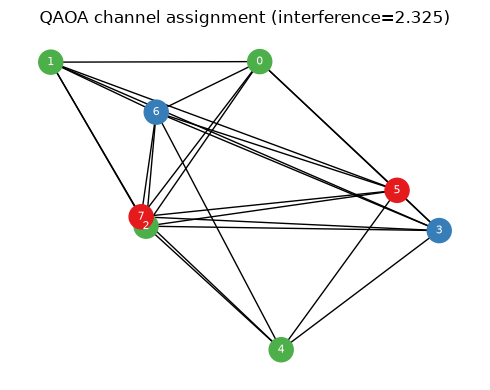

In [4]:
rc, enc_c = solve_cold(ig, encoding='onehot', penalty=6.0, reps=1, maxiter=120, seed=42)
print(f'cold QAOA:   interference={rc.objective:.4f}  feasible={rc.feasible}  iters={rc.n_iterations}  gap={rc.objective-bf_obj:.4f}')
print(f'brute force: {bf_obj:.4f}   greedy: {gd_obj:.4f}')
print(f'assignment: {rc.assignment}')

# Visualize the assignment as a coloured graph
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']
node_colors = [colors[rc.assignment[n] % len(colors)] for n in ig.graph.nodes]
fig, ax = plt.subplots(figsize=(5,4))
nx.draw(ig.graph, ig.positions, ax=ax, node_color=node_colors, with_labels=True, node_size=300, font_size=8, font_color='white')
ax.set_title(f'QAOA channel assignment (interference={rc.objective:.3f})')
plt.tight_layout(); plt.show()

## 4. Mobility dynamics: warm-start vs cold-start（headline result）

This is the main story of the demo. On a sequence of lightly perturbed interference graphs, both solvers get the **same tight optimizer budget**; warm-start is valuable if it lands closer to the optimum under that fixed budget.


In [7]:
MAXITER = 25

rep = run_dynamics(
    base=ig,
    n_snapshots=5,
    encoding='onehot',
    penalty=6.0,
    reps=1,
    maxiter=MAXITER,
    seed=42,
    perturb_seed=1,
)

rows = rep.iter_table()
mean_gap_reduction = rep.mean_cold_gap - rep.mean_warm_gap
warm_win_rate = rep.warm_better_count / len(rep.snapshots)

print(f"{'snap':>4} {'brute':>8} {'cold':>8} {'warm':>8} {'c_gap':>7} {'w_gap':>7} {'delta':>7} {'win':>6}")
for r in rows:
    delta = r['cold_gap'] - r['warm_gap']
    win = 'WARM' if r['warm_gap'] < r['cold_gap'] - 1e-9 else ''
    print(
        f"{r['snapshot']:>4} {r['brute']:>8.3f} {r['cold_obj']:>8.3f} {r['warm_obj']:>8.3f} "
        f"{r['cold_gap']:>7.3f} {r['warm_gap']:>7.3f} {delta:>7.3f} {win:>6}"
    )

print(f"\nMean gap: cold={rep.mean_cold_gap:.4f}  warm={rep.mean_warm_gap:.4f}")
print(f"Mean gap reduction (cold - warm): {mean_gap_reduction:+.4f}")
print(f"Warm-start wins: {rep.warm_better_count}/{len(rep.snapshots)} snapshots ({warm_win_rate:.0%})")


snap    brute     cold     warm   c_gap   w_gap   delta    win
   0    1.806    2.080    1.806   0.275   0.000   0.274   WARM
   1    1.065    1.565    1.178   0.500   0.113   0.387   WARM
   2    1.524    1.524    1.582   0.000   0.059  -0.059       
   3    1.794    2.146    1.794   0.352   0.000   0.352   WARM
   4    1.312    1.985    1.312   0.673   0.000   0.673   WARM

Mean gap: cold=0.3600  warm=0.0345
Mean gap reduction (cold - warm): +0.3256
Warm-start wins: 4/5 snapshots (80%)


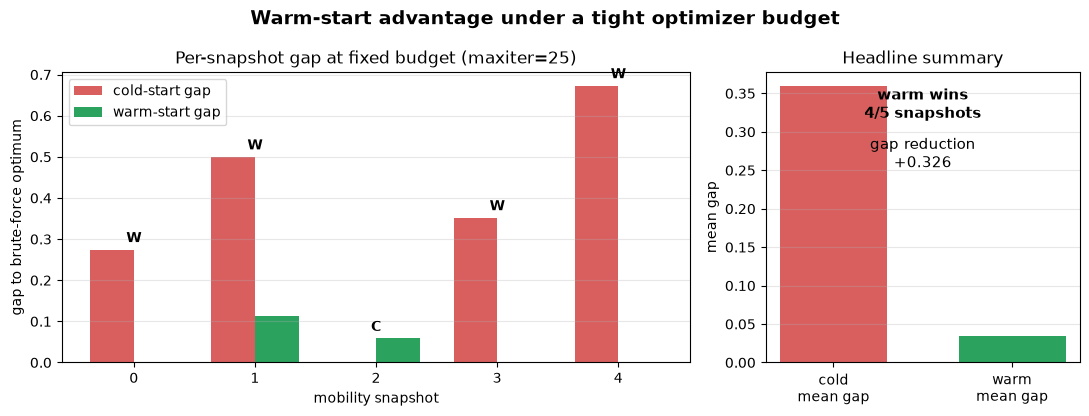

In [8]:
# Headline figure: gap-to-optimum bars, not qubit/depth curves
snaps = np.array([r['snapshot'] for r in rows], dtype=float)
cold_gap = np.array([r['cold_gap'] for r in rows], dtype=float)
warm_gap = np.array([r['warm_gap'] for r in rows], dtype=float)

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(11, 4.2),
    gridspec_kw={'width_ratios': [2.4, 1.2]},
)

bar_w = 0.36
ax1.bar(snaps - bar_w / 2, cold_gap, width=bar_w, color='#d95f5f', label='cold-start gap')
ax1.bar(snaps + bar_w / 2, warm_gap, width=bar_w, color='#2ca25f', label='warm-start gap')

for x, cg, wg in zip(snaps, cold_gap, warm_gap):
    winner = 'W' if wg < cg else 'C'
    ax1.text(x, max(cg, wg) + 0.01, winner, ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('mobility snapshot')
ax1.set_ylabel('gap to brute-force optimum')
ax1.set_title(f'Per-snapshot gap at fixed budget (maxiter={MAXITER})')
ax1.set_xticks(snaps)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

summary_labels = ['cold\nmean gap', 'warm\nmean gap']
summary_vals = [rep.mean_cold_gap, rep.mean_warm_gap]
summary_colors = ['#d95f5f', '#2ca25f']
ax2.bar(summary_labels, summary_vals, color=summary_colors, width=0.6)
ax2.set_ylabel('mean gap')
ax2.set_title('Headline summary')
ax2.grid(axis='y', alpha=0.3)
ax2.text(
    0.5,
    0.95,
    f'warm wins\n{rep.warm_better_count}/{len(rows)} snapshots',
    transform=ax2.transAxes,
    ha='center',
    va='top',
    fontsize=11,
    fontweight='bold',
)
ax2.text(
    0.5,
    0.78,
    f'gap reduction\n{mean_gap_reduction:+.3f}',
    transform=ax2.transAxes,
    ha='center',
    va='top',
    fontsize=11,
)

fig.suptitle('Warm-start advantage under a tight optimizer budget', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Encoding note（appendix）

binary vs one-hot is not the main message of this notebook. Keep it as a compact appendix table that explains the qubit-count vs Hamiltonian-density trade-off, without making it the headline figure.


In [9]:
appendix_rows = []
for (n, k) in [(8, 3), (10, 4)]:
    appendix_rows += encoding_study(n_cells=n, n_channels=k, reps=1, n_runs=2)

print_table(appendix_rows)


    graph     enc  qubits   depth   gates  feas%
    N8_K3  onehot      24      78     342    100
    N8_K3  binary      16      90     336    100
   N10_K4  onehot      40     129     756     --
   N10_K4  binary      20     114     546    100


## 6. Scalability point (mid-size graph)

A mid-size interference graph (the `MIDSIZE` preset: 14 cells, 4 channels). Brute force is intractable here (K^N); greedy and QAOA still run. Under the binary encoding this is 14×2 = 28 qubits, near the Aer SamplerV2 reliable width for this stack. This is the scale-bridge for the pitch.

In [10]:
mid = midsize_graph(seed=0)
print(f'mid-size: {mid.n_cells} cells, {mid.graph.number_of_edges()} edges, K={mid.n_channels}')
print(f'qubits one-hot={mid.n_cells*mid.n_channels}, binary={mid.n_cells*_keff(mid.n_channels)} (brute force would be {mid.n_channels**mid.n_cells} assignments)')
gd_a, gd_obj = greedy_dfs(mid)
print(f'greedy interference = {gd_obj:.4f}')
# QAOA on the binary encoding (fewer qubits -> fits the simulator at this scale)
r_mid, _ = solve_cold(mid, encoding='binary', penalty=10.0, reps=1, maxiter=80, seed=42)
print(f'QAOA (binary) interference = {r_mid.objective:.4f}  feasible={r_mid.feasible}  iters={r_mid.n_iterations}')
print(f'QAOA vs greedy: {r_mid.objective - gd_obj:+.4f}')

mid-size: 14 cells, 77 edges, K=4
qubits one-hot=56, binary=28 (brute force would be 268435456 assignments)
greedy interference = 2.1147
QAOA (binary) interference = 4.3839  feasible=True  iters=27
QAOA vs greedy: +2.2692


## Verification summary

- **QUBO correctness**: one-hot and binary QUBO optima both match the brute-force optimum.
- **Cold QAOA quality**: cold-start QAOA approaches brute force on the small graph and stays competitive with greedy.
- **Warm-start value**: under the same tight optimizer budget, warm-start is the main headline because it gets closer to the optimum on most mobility snapshots.
- **Encoding note**: binary reduces qubits while making the cost Hamiltonian denser; this is supporting context, not the main story.
- **Scalability**: the mid-size graph still runs with the binary encoding even when brute force is no longer practical.
